## Étape 1 — Préparation des données


### 1.1 Imports et configuration


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

### 1.2 Chargement des données


In [37]:
german_credit = fetch_ucirepo(id=144)
X_raw = german_credit.data.features.copy()
y_raw = german_credit.data.targets.copy()

print(f'Shape features : {X_raw.shape}')
print(f'Distribution cible :\n{y_raw["class"].value_counts()}')
print(f'Missing values : {X_raw.isnull().sum().sum()}')
X_raw.head()

Shape features : (1000, 20)
Distribution cible :
class
1    700
2    300
Name: count, dtype: int64
Missing values : 0


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


### 1.3 Définition de l'attribut sensible (Âge) & Encodage des variables


In [38]:
df = X_raw.copy()
df['class'] = y_raw['class'].values

AGE_THRESHOLD = 25
df['age_group'] = (df['Attribute13'] >= AGE_THRESHOLD).astype(int)  # 1=senior, 0=jeune

feature_cols = [c for c in df.columns if c not in ['class', 'age_group']]
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
num_cols = X_raw.select_dtypes(include='number').columns.tolist()

df_encoded = df.copy()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

df_encoded['target'] = (df_encoded['class'] == 2).astype(int)
print(df_encoded['target'].value_counts())

target
0    700
1    300
Name: count, dtype: int64


### 1.4 Split Train / Test stratifié (80/20) & Normalisation


In [39]:
X = df_encoded[feature_cols].values
y = df_encoded['target'].values
sensitive = df_encoded['age_group'].values

X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

num_indices = [feature_cols.index(c) for c in num_cols]
scaler = StandardScaler()
X_train_scaled = X_train.copy().astype(float)
X_test_scaled  = X_test.copy().astype(float)
X_train_scaled[:, num_indices] = scaler.fit_transform(X_train[:, num_indices])
X_test_scaled[:, num_indices]  = scaler.transform(X_test[:, num_indices])

print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')

Train : 800 | Test : 200


### 1.5 Visualisation exploratoire (EDA)


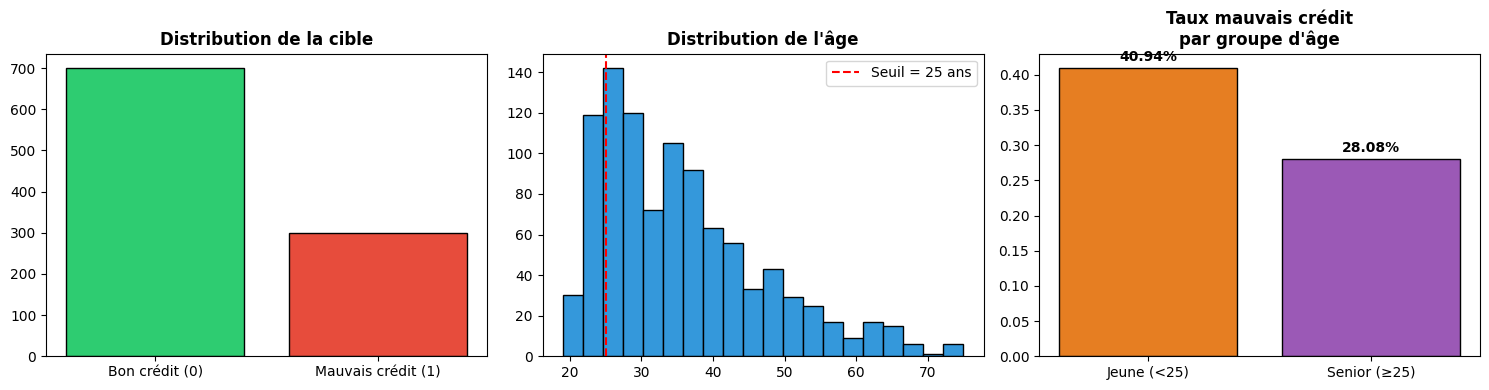

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(['Bon crédit (0)', 'Mauvais crédit (1)'],
            df_encoded['target'].value_counts().sort_index(),
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribution de la cible', fontweight='bold')

axes[1].hist(df['Attribute13'], bins=20, color='#3498db', edgecolor='black')
axes[1].axvline(AGE_THRESHOLD, color='red', linestyle='--', label=f'Seuil = {AGE_THRESHOLD} ans')
axes[1].set_title("Distribution de l'âge", fontweight='bold')
axes[1].legend()

rate_by_age = df_encoded.groupby('age_group')['target'].mean()
axes[2].bar(['Jeune (<25)', 'Senior (≥25)'], rate_by_age.values,
            color=['#e67e22', '#9b59b6'], edgecolor='black')
axes[2].set_title("Taux mauvais crédit\npar groupe d'âge", fontweight='bold')
for i, v in enumerate(rate_by_age.values):
    axes[2].text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Étape 2 — Modèle Baseline

### 2.1 Cost Matrix & Entraînement des modèles (Logistic Regression & Random Forest)


In [41]:
CLASS_WEIGHT = {0: 1, 1: 5}

def cost_matrix_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm[1, 0] * 5 + cm[0, 1] * 1

lr = LogisticRegression(max_iter=1000, class_weight=CLASS_WEIGHT, random_state=SEED)
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             class_weight=CLASS_WEIGHT, random_state=SEED, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
print('Modèles entraînés ✓')

Modèles entraînés ✓


### 2.2 Évaluation sur le jeu de test


In [42]:
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        'Modèle'     : name,
        'Accuracy'   : accuracy_score(y_te, y_pred),
        'F1 (macro)' : f1_score(y_te, y_pred, average='macro'),
        'F1 (bad)'   : f1_score(y_te, y_pred, pos_label=1),
        'AUC-ROC'    : roc_auc_score(y_te, y_prob),
        'Coût total' : cost_matrix_score(y_te, y_pred),
    }

results_df = pd.DataFrame([
    evaluate_model('Logistic Regression', lr, X_test_scaled, y_test),
    evaluate_model('Random Forest',       rf, X_test_scaled, y_test),
]).set_index('Modèle')

print(results_df.round(4).to_string())

                     Accuracy  F1 (macro)  F1 (bad)  AUC-ROC  Coût total
Modèle                                                                  
Logistic Regression     0.605      0.6033    0.5775   0.7923         103
Random Forest           0.730      0.6992    0.6029   0.8035         130


### 2.3 Matrices de confusion


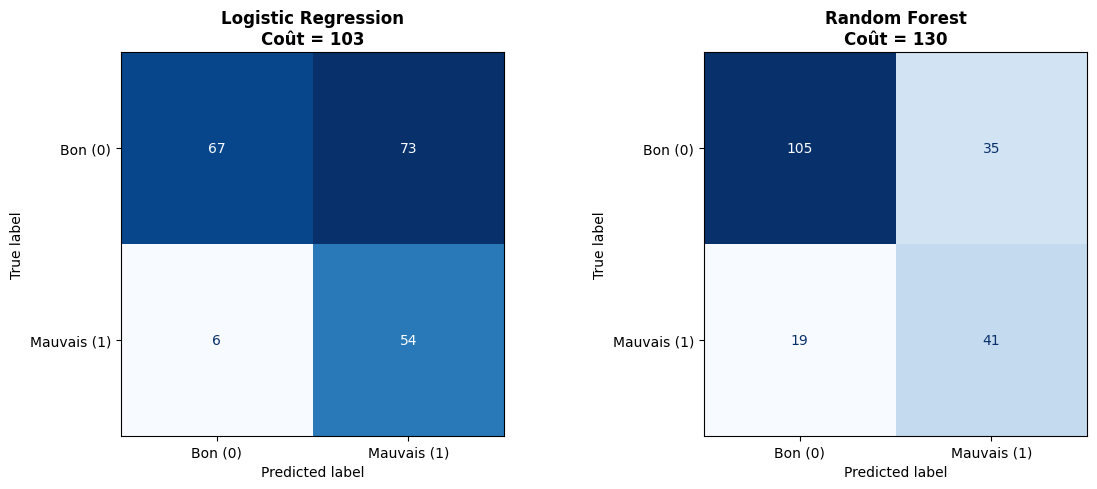

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, [('Logistic Regression', lr), ('Random Forest', rf)]):
    y_pred = model.predict(X_test_scaled)
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=['Bon (0)', 'Mauvais (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nCoût = {cost_matrix_score(y_test, y_pred)}', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Validation croisée (5-fold stratifiée)


In [44]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    auc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    f1  = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_macro')
    print(f'{name}: AUC={auc.mean():.4f}±{auc.std():.4f} | F1={f1.mean():.4f}±{f1.std():.4f}')

Logistic Regression: AUC=0.7763±0.0554 | F1=0.6048±0.0257
Random Forest: AUC=0.7829±0.0411 | F1=0.6960±0.0329


### 2.5 Métriques de fairness préliminaires (avant mitigation)


In [45]:
def fairness_metrics(y_true, y_pred, sensitive, model_name=''):
    mask_young  = sensitive == 0
    mask_senior = sensitive == 1
    pr_young  = (y_pred[mask_young]  == 0).mean()
    pr_senior = (y_pred[mask_senior] == 0).mean()
    DI  = pr_young / pr_senior
    EOD = y_pred[mask_young & (y_true==1)].mean() - y_pred[mask_senior & (y_true==1)].mean()
    print(f'\n=== {model_name} ===')
    print(f'  DI  = {DI:.3f}  (idéal=1.0, seuil légal ≥ 0.8)')
    print(f'  EOD = {EOD:.3f}  (idéal=0.0)')

fairness_metrics(y_test, lr.predict(X_test_scaled), s_test, 'Logistic Regression')
fairness_metrics(y_test, rf.predict(X_test_scaled), s_test, 'Random Forest')


=== Logistic Regression ===
  DI  = 0.370  (idéal=1.0, seuil légal ≥ 0.8)
  EOD = 0.069  (idéal=0.0)

=== Random Forest ===
  DI  = 0.656  (idéal=1.0, seuil légal ≥ 0.8)
  EOD = 0.078  (idéal=0.0)


### 2.6 Sauvegarde du checkpoint


In [46]:
import pickle
checkpoint = {
    'X_train': X_train_scaled, 'X_test': X_test_scaled,
    'y_train': y_train, 'y_test': y_test,
    's_train': s_train, 's_test': s_test,
    'feature_cols': feature_cols, 'scaler': scaler, 'le_dict': le_dict,
    'baseline_lr': lr, 'baseline_rf': rf, 'SEED': SEED,
}
with open('checkpoint_etapes1_2.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)
print('Checkpoint sauvegardé ✓')

Checkpoint sauvegardé ✓


## Étape 3 — Équité Algorithmique : Méthodes de Mitigation

### 3.1 Chargement du checkpoint & Extraction du genre


In [47]:
import pickle
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix)
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds, DemographicParity
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Chargement checkpoint
with open('checkpoint_etapes1_2.pkl', 'rb') as f:
    ck = pickle.load(f)

X_train = ck['X_train']
X_test  = ck['X_test']
y_train = ck['y_train']
y_test  = ck['y_test']
s_train = ck['s_train']  # âge
s_test  = ck['s_test']
feature_cols = ck['feature_cols']
lr_base = ck['baseline_lr']
rf_base = ck['baseline_rf']
SEED = ck['SEED']

print('Checkpoint chargé ✓')

Checkpoint chargé ✓


### 3.2 Extraction du genre (Attribute9) & Reconstruction du split


In [48]:
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

german_credit = fetch_ucirepo(id=144)
X_raw = german_credit.data.features.copy()
y_raw = german_credit.data.targets.copy()

# Extraction genre depuis Attribute9
# A91/A93/A94 = male, A92/A95 = female
gender_map = {
    'A91': 0,  # male
    'A92': 1,  # female
    'A93': 0,  # male
    'A94': 0,  # male
    'A95': 1,  # female
}
gender = X_raw['Attribute9'].map(gender_map).values  # 0=male, 1=female

# Âge (déjà calculé)
age_group = (X_raw['Attribute13'] >= 25).astype(int).values  # 0=jeune, 1=senior

# Target
target = (y_raw['class'] == 2).astype(int).values

# On refait le même split avec random_state=42 pour être cohérent
from sklearn.model_selection import train_test_split
idx = np.arange(len(target))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=SEED, stratify=target)

gender_train, gender_test = gender[idx_train], gender[idx_test]
age_train,    age_test    = age_group[idx_train], age_group[idx_test]

print(f'Distribution genre — Train: {pd.Series(gender_train).value_counts().to_dict()}')
print(f'Distribution genre — Test : {pd.Series(gender_test).value_counts().to_dict()}')
print(f'  0 = male | 1 = female')

Distribution genre — Train: {0: 551, 1: 249}
Distribution genre — Test : {0: 139, 1: 61}
  0 = male | 1 = female


### 3.3 Fonction d'évaluation complète (Performance + Fairness)


In [49]:
def cost_matrix_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm[1, 0] * 5 + cm[0, 1] * 1

def evaluate_full(name, y_true, y_pred, y_prob, sensitive_age, sensitive_gender):
    """Métriques performance + fairness âge + fairness genre."""
    
    # Performance
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro')
    auc  = roc_auc_score(y_true, y_prob)
    cost = cost_matrix_score(y_true, y_pred)
    
    # Fairness — Âge
    di_age  = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive_age)
    eod_age = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive_age)
    
    # Fairness — Genre
    di_gender  = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive_gender)
    eod_gender = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive_gender)
    
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  F1 macro  : {f1:.4f}')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  Coût      : {cost}')
    print(f'  --- Fairness Âge ---')
    print(f'  DP diff   : {di_age:.4f}   (idéal=0, |val|<0.1 acceptable)')
    print(f'  EOD       : {eod_age:.4f}   (idéal=0)')
    print(f'  --- Fairness Genre ---')
    print(f'  DP diff   : {di_gender:.4f}   (idéal=0)')
    print(f'  EOD       : {di_gender:.4f}   (idéal=0)')
    
    return {
        'Modèle': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc, 'Coût': cost,
        'DP_age': di_age, 'EOD_age': eod_age,
        'DP_gender': di_gender, 'EOD_gender': eod_gender
    }

print('Fonction définie ✓')

Fonction définie ✓


### 3.4 Scores de référence baseline (avant mitigation)


In [50]:
# Scores baseline (avant mitigation) — référence
print('=== BASELINE (avant mitigation) ===')
baseline_results = []

for name, model in [('LR baseline', lr_base), ('RF baseline', rf_base)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    r = evaluate_full(name, y_test, y_pred, y_prob, age_test, gender_test)
    baseline_results.append(r)

=== BASELINE (avant mitigation) ===

  LR baseline
  Accuracy  : 0.6050
  F1 macro  : 0.6033
  AUC-ROC   : 0.7923
  Coût      : 103
  --- Fairness Âge ---
  DP diff   : 0.2623   (idéal=0, |val|<0.1 acceptable)
  EOD       : 0.2667   (idéal=0)
  --- Fairness Genre ---
  DP diff   : 0.1242   (idéal=0)
  EOD       : 0.1242   (idéal=0)

  RF baseline
  Accuracy  : 0.7300
  F1 macro  : 0.6992
  AUC-ROC   : 0.8035
  Coût      : 130
  --- Fairness Âge ---
  DP diff   : 0.2287   (idéal=0, |val|<0.1 acceptable)
  EOD       : 0.1750   (idéal=0)
  --- Fairness Genre ---
  DP diff   : 0.1373   (idéal=0)
  EOD       : 0.1373   (idéal=0)


### 3.5 Méthode 1 : Reweighing (pré-traitement)

Calcul des poids pour équilibrer la représentation des groupes (âge, genre, combiné) dans l'entraînement.


In [51]:
# Reweighing : on calcule des poids pour équilibrer la représentation
# des groupes (âge x genre x target) dans l'entraînement

def compute_reweighing_weights(y, sensitive):
    """Calcule les poids de reweighing pour un attribut sensible."""
    df_w = pd.DataFrame({'y': y, 's': sensitive})
    n = len(df_w)
    
    # P(s) et P(y)
    p_s = df_w['s'].value_counts(normalize=True)
    p_y = df_w['y'].value_counts(normalize=True)
    
    weights = np.ones(n)
    for i, row in df_w.iterrows():
        p_sy = len(df_w[(df_w['s']==row['s']) & (df_w['y']==row['y'])]) / n
        w = (p_s[row['s']] * p_y[row['y']]) / p_sy
        weights[i] = w
    return weights

# Reweighing sur l'âge
w_age = compute_reweighing_weights(y_train, age_train)

# Reweighing sur le genre
w_gender = compute_reweighing_weights(y_train, gender_train)

# Reweighing combiné (âge + genre) — on multiplie et normalise
w_combined = w_age * w_gender
w_combined = w_combined / w_combined.mean()  # normalisation

print(f'Poids reweighing âge    — min:{w_age.min():.3f} max:{w_age.max():.3f}')
print(f'Poids reweighing genre  — min:{w_gender.min():.3f} max:{w_gender.max():.3f}')
print(f'Poids reweighing combiné— min:{w_combined.min():.3f} max:{w_combined.max():.3f}')

Poids reweighing âge    — min:0.786 max:1.132
Poids reweighing genre  — min:0.839 max:1.095
Poids reweighing combiné— min:0.659 max:1.232


### 3.6 Entraînement des modèles avec Reweighing


In [52]:
CLASS_WEIGHT = {0: 1, 1: 5}

# LR avec reweighing âge
lr_rw_age = LogisticRegression(max_iter=1000, class_weight=CLASS_WEIGHT, random_state=SEED)
lr_rw_age.fit(X_train, y_train, sample_weight=w_age)

# RF avec reweighing âge
rf_rw_age = RandomForestClassifier(n_estimators=200, max_depth=8,
                                    class_weight=CLASS_WEIGHT, random_state=SEED, n_jobs=-1)
rf_rw_age.fit(X_train, y_train, sample_weight=w_age)

# RF avec reweighing genre
rf_rw_gender = RandomForestClassifier(n_estimators=200, max_depth=8,
                                       class_weight=CLASS_WEIGHT, random_state=SEED, n_jobs=-1)
rf_rw_gender.fit(X_train, y_train, sample_weight=w_gender)

# RF avec reweighing combiné
rf_rw_combined = RandomForestClassifier(n_estimators=200, max_depth=8,
                                         class_weight=CLASS_WEIGHT, random_state=SEED, n_jobs=-1)
rf_rw_combined.fit(X_train, y_train, sample_weight=w_combined)

print('Modèles reweighing entraînés ✓')

Modèles reweighing entraînés ✓


### 3.7 Méthode 2 : Fairlearn — ExponentiatedGradient (en cours d'apprentissage)

- `EqualizedOdds` appliqué sur l'âge
- `DemographicParity` appliqué sur le genre


In [53]:
# ExponentiatedGradient avec contrainte EqualizedOdds sur l'âge
eg_age = ExponentiatedGradient(
    estimator=RandomForestClassifier(n_estimators=100, max_depth=8,
                                      class_weight=CLASS_WEIGHT, random_state=SEED),
    constraints=EqualizedOdds(),
    max_iter=50
)
eg_age.fit(X_train, y_train, sensitive_features=age_train)

# ExponentiatedGradient avec contrainte DemographicParity sur le genre
eg_gender = ExponentiatedGradient(
    estimator=RandomForestClassifier(n_estimators=100, max_depth=8,
                                      class_weight=CLASS_WEIGHT, random_state=SEED),
    constraints=DemographicParity(),
    max_iter=50
)
eg_gender.fit(X_train, y_train, sensitive_features=gender_train)

print('Modèles Fairlearn entraînés ✓')

Modèles Fairlearn entraînés ✓


### 3.8 Évaluation comparative — tous les modèles


In [54]:
print('\n=== ÉVALUATION COMPLÈTE ===')
all_results = baseline_results.copy()

models_to_eval = [
    ('LR + Reweighing (âge)',      lr_rw_age),
    ('RF + Reweighing (âge)',      rf_rw_age),
    ('RF + Reweighing (genre)',    rf_rw_gender),
    ('RF + Reweighing (combiné)',  rf_rw_combined),
    ('RF + Fairlearn EO (âge)',    eg_age),
    ('RF + Fairlearn DP (genre)',  eg_gender),
]

for name, model in models_to_eval:
    y_pred = model.predict(X_test)
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except:
        y_prob = model._pmf_predict(X_test)[:, 1]
    r = evaluate_full(name, y_test, y_pred, y_prob, age_test, gender_test)
    all_results.append(r)


=== ÉVALUATION COMPLÈTE ===

  LR + Reweighing (âge)
  Accuracy  : 0.5900
  F1 macro  : 0.5890
  AUC-ROC   : 0.7888
  Coût      : 106
  --- Fairness Âge ---
  DP diff   : 0.2437   (idéal=0, |val|<0.1 acceptable)
  EOD       : 0.2417   (idéal=0)
  --- Fairness Genre ---
  DP diff   : 0.1026   (idéal=0)
  EOD       : 0.1026   (idéal=0)

  RF + Reweighing (âge)
  Accuracy  : 0.7400
  F1 macro  : 0.7103
  AUC-ROC   : 0.8005
  Coût      : 124
  --- Fairness Âge ---
  DP diff   : 0.1650   (idéal=0, |val|<0.1 acceptable)
  EOD       : 0.0667   (idéal=0)
  --- Fairness Genre ---
  DP diff   : 0.0665   (idéal=0)
  EOD       : 0.0665   (idéal=0)

  RF + Reweighing (genre)
  Accuracy  : 0.7300
  F1 macro  : 0.6970
  AUC-ROC   : 0.8054
  Coût      : 134
  --- Fairness Âge ---
  DP diff   : 0.2093   (idéal=0, |val|<0.1 acceptable)
  EOD       : 0.1250   (idéal=0)
  --- Fairness Genre ---
  DP diff   : 0.0809   (idéal=0)
  EOD       : 0.0809   (idéal=0)

  RF + Reweighing (combiné)
  Accuracy  : 0.

### 3.9 Tableau comparatif & Graphique des compromis Performance / Équité



=== TABLEAU COMPARATIF ===
                           Accuracy      F1     AUC  Coût  DP_age  EOD_age  DP_gender  EOD_gender
Modèle                                                                                           
LR baseline                   0.605  0.6033  0.7923   103  0.2623   0.2667     0.1242      0.1249
RF baseline                   0.730  0.6992  0.8035   130  0.2287   0.1750     0.1373      0.1293
LR + Reweighing (âge)         0.590  0.5890  0.7888   106  0.2437   0.2417     0.1026      0.0946
RF + Reweighing (âge)         0.740  0.7103  0.8005   124  0.1650   0.0667     0.0665      0.0750
RF + Reweighing (genre)       0.730  0.6970  0.8054   134  0.2093   0.1250     0.0809      0.1250
RF + Reweighing (combiné)     0.760  0.7326  0.8106   112  0.1650   0.0833     0.0665      0.0562
RF + Fairlearn EO (âge)       0.715  0.6858  0.7411   133  0.0508   0.0757     0.0449      0.0645
RF + Fairlearn DP (genre)     0.730  0.6970  0.7372   134  0.1774   0.1027     0.0573     

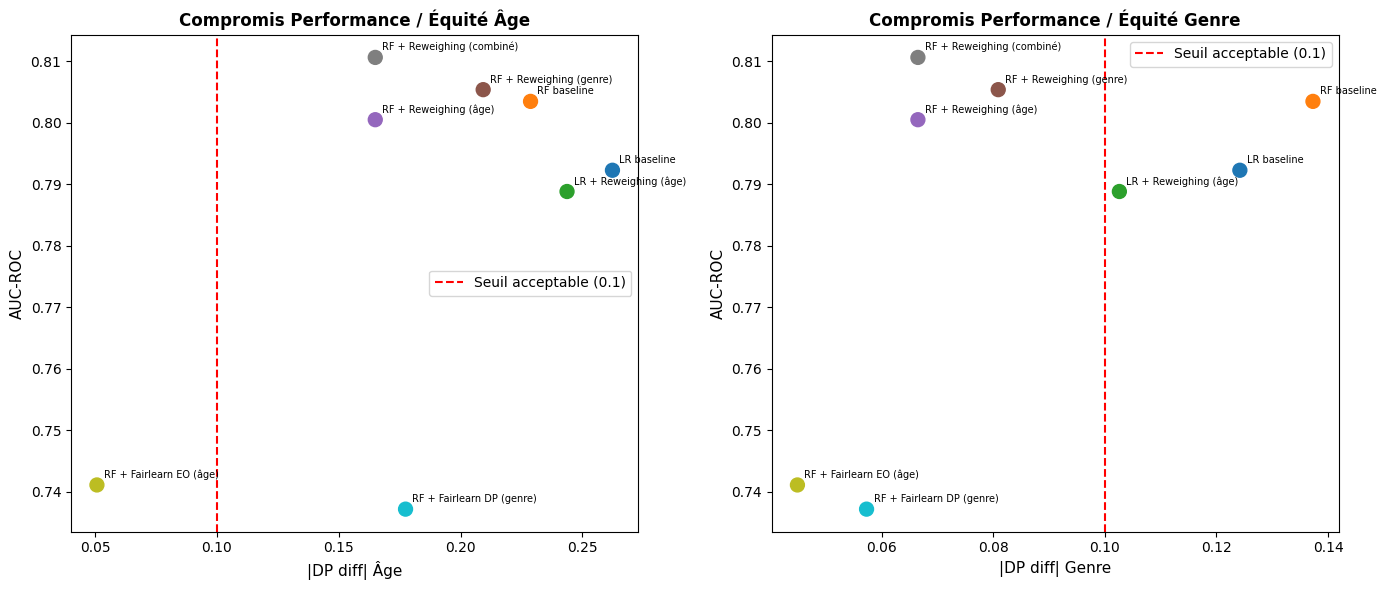

Figure sauvegardée : fairness_tradeoff.png


In [55]:
results_df = pd.DataFrame(all_results).set_index('Modèle')
print('\n=== TABLEAU COMPARATIF ===')
print(results_df.round(4).to_string())

# Graphique : AUC vs DP_age
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# AUC vs Fairness âge
axes[0].scatter(results_df['DP_age'].abs(), results_df['AUC'],
                s=100, c=range(len(results_df)), cmap='tab10', zorder=5)
for i, (idx, row) in enumerate(results_df.iterrows()):
    axes[0].annotate(idx, (abs(row['DP_age']), row['AUC']),
                     textcoords='offset points', xytext=(5, 5), fontsize=7)
axes[0].axvline(0.1, color='red', linestyle='--', label='Seuil acceptable (0.1)')
axes[0].set_xlabel('|DP diff| Âge', fontsize=11)
axes[0].set_ylabel('AUC-ROC', fontsize=11)
axes[0].set_title('Compromis Performance / Équité Âge', fontweight='bold')
axes[0].legend()

# AUC vs Fairness genre
axes[1].scatter(results_df['DP_gender'].abs(), results_df['AUC'],
                s=100, c=range(len(results_df)), cmap='tab10', zorder=5)
for i, (idx, row) in enumerate(results_df.iterrows()):
    axes[1].annotate(idx, (abs(row['DP_gender']), row['AUC']),
                     textcoords='offset points', xytext=(5, 5), fontsize=7)
axes[1].axvline(0.1, color='red', linestyle='--', label='Seuil acceptable (0.1)')
axes[1].set_xlabel('|DP diff| Genre', fontsize=11)
axes[1].set_ylabel('AUC-ROC', fontsize=11)
axes[1].set_title('Compromis Performance / Équité Genre', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fairness_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : fairness_tradeoff.png')

### 3.10 Sauvegarde du checkpoint étape 3


In [56]:
with open('checkpoint_etape3.pkl', 'wb') as f:
    pickle.dump({
        'rf_rw_age': rf_rw_age,
        'rf_rw_gender': rf_rw_gender,
        'rf_rw_combined': rf_rw_combined,
        'eg_age': eg_age,
        'eg_gender': eg_gender,
        'age_test': age_test,
        'gender_test': gender_test,
        'results_df': results_df,
        'SEED': SEED,
    }, f)
print('Checkpoint étape 3 sauvegardé ✓')

Checkpoint étape 3 sauvegardé ✓


## Étape 4 — Interprétabilité du modèle retenu

L'analyse porte sur le modèle `RF + Reweighing (combiné)`, retenu pour son compromis performance/fairness. L'objectif est d'auditer son comportement : identifier les variables qui influencent les prédictions et vérifier si des attributs sensibles ou leurs proxies restent importants. Les résultats décrivent le modèle entraîné, pas des relations causales.

### 4.1 Choix du modèle et préparation des données

In [57]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Modele retenu d'apres le tableau de compromis: meilleure AUC/F1, cout plus faible,
# et reduction nette des ecarts DP/EOD par rapport au Random Forest baseline.
interpreted_model = rf_rw_combined
interpreted_model_name = 'RF + Reweighing (combine)'

X_train_df = pd.DataFrame(X_train, columns=feature_cols)
X_test_df = pd.DataFrame(X_test, columns=feature_cols)

feature_labels = {
    'Attribute1': 'checking_account_status',
    'Attribute2': 'duration_months',
    'Attribute3': 'credit_history',
    'Attribute4': 'purpose',
    'Attribute5': 'credit_amount',
    'Attribute6': 'savings_account',
    'Attribute7': 'employment_since',
    'Attribute8': 'installment_rate',
    'Attribute9': 'personal_status_sex',
    'Attribute10': 'other_debtors',
    'Attribute11': 'residence_since',
    'Attribute12': 'property',
    'Attribute13': 'age',
    'Attribute14': 'other_installment_plans',
    'Attribute15': 'housing',
    'Attribute16': 'existing_credits',
    'Attribute17': 'job',
    'Attribute18': 'people_liable',
    'Attribute19': 'telephone',
    'Attribute20': 'foreign_worker',
}

sensitive_or_proxy = {
    'Attribute9': 'gender / personal status',
    'Attribute13': 'age',
    'Attribute15': 'housing, possible socio-economic proxy',
    'Attribute17': 'job, possible socio-economic proxy',
    'Attribute20': 'foreign worker',
}

print(f'Modele interprete : {interpreted_model_name}')
print(f'Features analysees : {len(feature_cols)}')

Modele interprete : RF + Reweighing (combine)
Features analysees : 20


### 4.2 Importance globale des variables

L'importance interne du Random Forest indique quelles variables sont souvent utilisées dans les arbres. Comme cette mesure peut favoriser certaines variables continues ou très découpées, elle sert seulement de premier repère avant la permutation importance.

Top 10 variables selon importance interne du Random Forest


,feature,label,importance_gini,sensitive_or_proxy
0,Attribute1,checking_account_status,0.164650,
4,Attribute5,credit_amount,0.114418,
1,Attribute2,duration_months,0.109974,
12,Attribute13,age,0.076758,age
5,Attribute6,savings_account,0.067158,
2,Attribute3,credit_history,0.058912,
3,Attribute4,purpose,0.053351,
6,Attribute7,employment_since,0.050055,
11,Attribute12,property,0.043515,
13,Attribute14,other_installment_plans,0.042427,


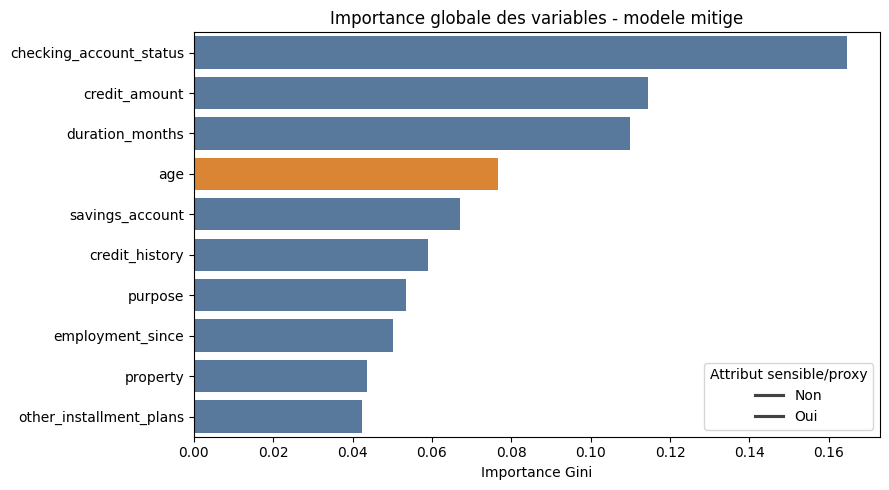

In [58]:
gini_importance = pd.DataFrame({
    'feature': feature_cols,
    'label': [feature_labels.get(c, c) for c in feature_cols],
    'importance_gini': interpreted_model.feature_importances_,
    'sensitive_or_proxy': [sensitive_or_proxy.get(c, '') for c in feature_cols],
}).sort_values('importance_gini', ascending=False)

print('Top 10 variables selon importance interne du Random Forest')
display(gini_importance.head(10))

plt.figure(figsize=(9, 5))
top_gini = gini_importance.head(10).copy()
sns.barplot(
    data=top_gini,
    x='importance_gini',
    y='label',
    hue=top_gini['sensitive_or_proxy'].ne(''),
    dodge=False,
    palette={False: '#4C78A8', True: '#F58518'}
)
plt.title('Importance globale des variables - modele mitige')
plt.xlabel('Importance Gini')
plt.ylabel('')
plt.legend(title='Attribut sensible/proxy', labels=['Non', 'Oui'])
plt.tight_layout()
plt.show()

### 4.3 Permutation importance sur le jeu de test

La permutation importance mesure la baisse d'AUC quand une variable est mélangée dans le jeu de test. Une forte baisse signifie que cette variable contribue fortement à la performance prédictive du modèle.

Top 10 variables selon permutation importance (baisse moyenne AUC)


,feature,label,importance_mean_auc_drop,importance_std,sensitive_or_proxy
0,Attribute1,checking_account_status,0.148914,0.031869,
1,Attribute2,duration_months,0.016990,0.013668,
5,Attribute6,savings_account,0.016905,0.015314,
9,Attribute10,other_debtors,0.016319,0.006328,
2,Attribute3,credit_history,0.015776,0.010016,
4,Attribute5,credit_amount,0.013352,0.005810,
13,Attribute14,other_installment_plans,0.010200,0.004298,
6,Attribute7,employment_since,0.008700,0.005532,
3,Attribute4,purpose,0.008671,0.003125,
12,Attribute13,age,0.008533,0.003235,age


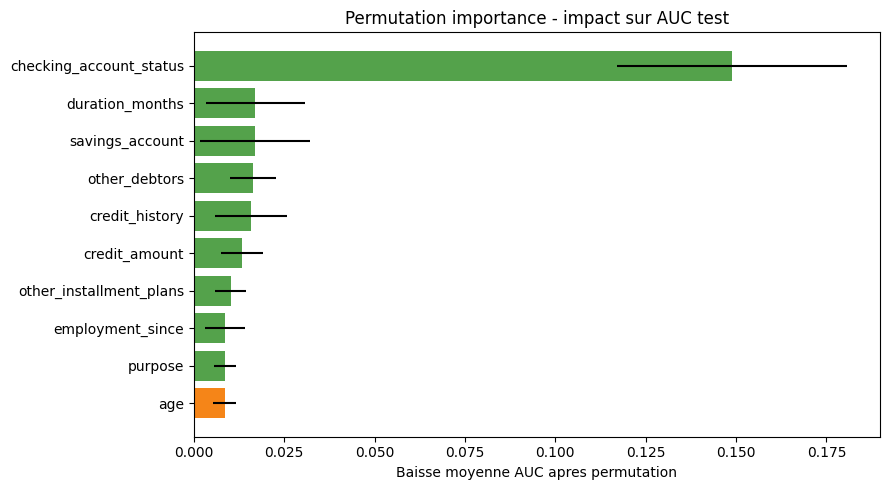

In [59]:
perm = permutation_importance(
    interpreted_model,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=25,
    random_state=SEED,
    n_jobs=-1,
)

perm_importance = pd.DataFrame({
    'feature': feature_cols,
    'label': [feature_labels.get(c, c) for c in feature_cols],
    'importance_mean_auc_drop': perm.importances_mean,
    'importance_std': perm.importances_std,
    'sensitive_or_proxy': [sensitive_or_proxy.get(c, '') for c in feature_cols],
}).sort_values('importance_mean_auc_drop', ascending=False)

print('Top 10 variables selon permutation importance (baisse moyenne AUC)')
display(perm_importance.head(10))

plt.figure(figsize=(9, 5))
top_perm = perm_importance.head(10).copy()
colors = np.where(top_perm['sensitive_or_proxy'].ne(''), '#F58518', '#54A24B')
plt.barh(top_perm['label'][::-1], top_perm['importance_mean_auc_drop'][::-1],
         xerr=top_perm['importance_std'][::-1], color=colors[::-1])
plt.title('Permutation importance - impact sur AUC test')
plt.xlabel('Baisse moyenne AUC apres permutation')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 4.4 Vérification des attributs sensibles et des proxies

La mitigation réduit certains écarts entre groupes, mais elle ne garantit pas que le modèle ignore les informations sensibles. Cette cellule vérifie donc le rang de l'âge, du genre/statut personnel et de quelques proxies plausibles dans les classements d'importance.

In [60]:
audit = (
    gini_importance[['feature', 'label', 'importance_gini', 'sensitive_or_proxy']]
    .merge(
        perm_importance[['feature', 'importance_mean_auc_drop', 'importance_std']],
        on='feature',
        how='left'
    )
)
audit['rank_gini'] = audit['importance_gini'].rank(ascending=False, method='min').astype(int)
audit['rank_permutation'] = audit['importance_mean_auc_drop'].rank(ascending=False, method='min').astype(int)
proxy_audit = audit[audit['feature'].isin(sensitive_or_proxy.keys())].sort_values('rank_permutation')

display(proxy_audit[[
    'feature', 'label', 'sensitive_or_proxy', 'rank_gini', 'importance_gini',
    'rank_permutation', 'importance_mean_auc_drop', 'importance_std'
]])

important_proxy = proxy_audit[
    (proxy_audit['rank_permutation'] <= 10) | (proxy_audit['rank_gini'] <= 10)
]
if len(important_proxy) == 0:
    print('Aucun attribut sensible/proxy predefini dans le top 10 des importances.')
else:
    print('Points de vigilance :')
    for _, row in important_proxy.iterrows():
        print(f"- {row['label']} ({row['sensitive_or_proxy']}) : "
              f"rang Gini={row['rank_gini']}, rang permutation={row['rank_permutation']}")

,feature,label,sensitive_or_proxy,rank_gini,importance_gini,rank_permutation,importance_mean_auc_drop,importance_std
3,Attribute13,age,age,4,0.076758,10,0.008533,0.003235
12,Attribute17,job,"job, possible socio-economic proxy",13,0.025488,12,0.004433,0.001926
13,Attribute9,personal_status_sex,gender / personal status,14,0.024809,14,0.004014,0.001781
19,Attribute20,foreign_worker,foreign worker,20,0.010158,17,0.001043,0.002902
14,Attribute15,housing,"housing, possible socio-economic proxy",15,0.021915,20,-0.000695,0.001691


Points de vigilance :
- age (age) : rang Gini=4, rang permutation=10


### 4.5 SHAP : importance globale et explication locale

SHAP attribue à chaque variable une contribution à la probabilité prédite de mauvais crédit. La moyenne des valeurs absolues donne une importance globale comparable aux classements précédents. Pour une observation donnée, une contribution positive pousse la prédiction vers `mauvais crédit`, tandis qu'une contribution négative la pousse vers `bon crédit`.

Top 10 variables selon SHAP (contribution moyenne absolue)


,feature,label,mean_abs_shap,sensitive_or_proxy,rank_shap
0,Attribute1,checking_account_status,0.130035,,1
5,Attribute6,savings_account,0.068783,,2
1,Attribute2,duration_months,0.051082,,3
2,Attribute3,credit_history,0.044196,,4
11,Attribute12,property,0.018244,,5
6,Attribute7,employment_since,0.016120,,6
7,Attribute8,installment_rate,0.014905,,7
13,Attribute14,other_installment_plans,0.013292,,8
4,Attribute5,credit_amount,0.013202,,9
9,Attribute10,other_debtors,0.011567,,10


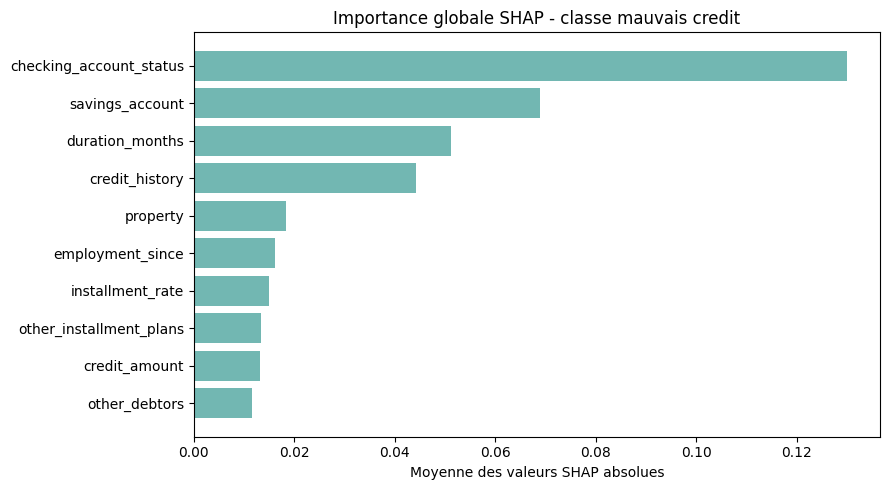

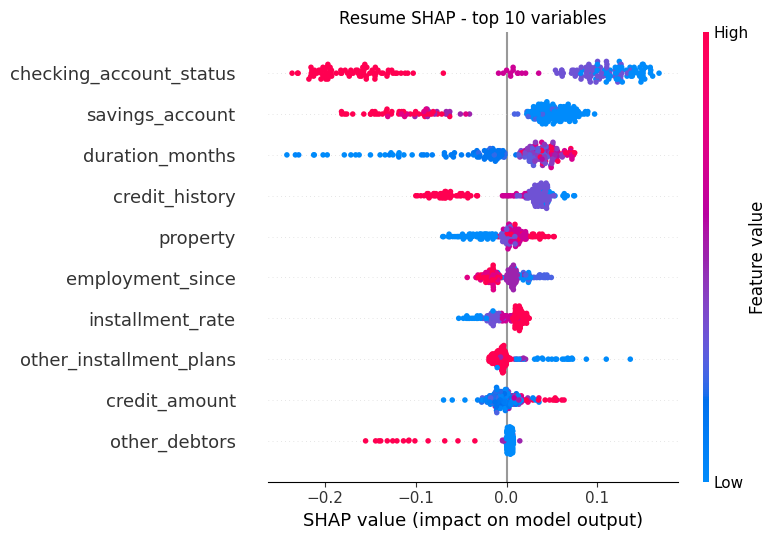

Position des attributs sensibles/proxies selon SHAP


,feature,label,sensitive_or_proxy,rank_shap,mean_abs_shap
12,Attribute13,age,age,11,0.010376
8,Attribute9,personal_status_sex,gender / personal status,15,0.004380
16,Attribute17,job,"job, possible socio-economic proxy",16,0.004043
19,Attribute20,foreign_worker,foreign worker,17,0.003766
14,Attribute15,housing,"housing, possible socio-economic proxy",19,0.002475


Observation test expliquee par SHAP : index local 2
Probabilite mauvais credit=0.754


,feature,label,shap_contribution,abs_shap_contribution,sensitive_or_proxy
0,Attribute1,checking_account_status,0.150670,0.150670,
1,Attribute2,duration_months,0.063292,0.063292,
5,Attribute6,savings_account,0.058592,0.058592,
11,Attribute12,property,-0.043529,0.043529,
6,Attribute7,employment_since,0.021239,0.021239,
2,Attribute3,credit_history,0.020194,0.020194,
13,Attribute14,other_installment_plans,0.018641,0.018641,
7,Attribute8,installment_rate,0.017734,0.017734,


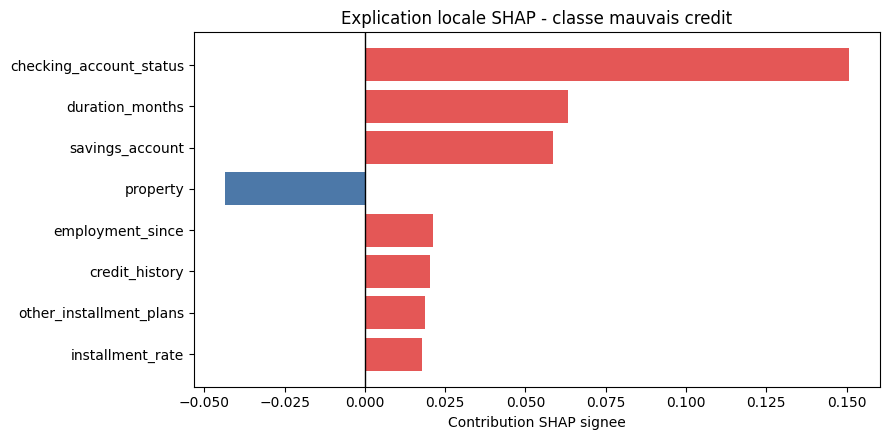

In [62]:
try:
    import shap
except ImportError as exc:
    raise ImportError(
        "SHAP n'est pas installe. Lancez `uv add shap` ou `pip install shap`, "
        "puis reexecutez cette cellule."
    ) from exc

# Echantillons reduits pour garder une execution rapide et reproductible.
shap_background = shap.sample(
    X_train_df,
    min(100, len(X_train_df)),
    random_state=SEED,
)
shap_eval = X_test_df.sample(
    n=min(200, len(X_test_df)),
    random_state=SEED,
)

shap_explainer = shap.TreeExplainer(
    interpreted_model,
    data=shap_background,
    feature_names=display_feature_names,
    model_output='probability',
)

shap_values_raw = shap_explainer.shap_values(shap_eval)
if isinstance(shap_values_raw, list):
    shap_values_class1 = shap_values_raw[1]
elif np.asarray(shap_values_raw).ndim == 3:
    shap_values_class1 = np.asarray(shap_values_raw)[:, :, 1]
else:
    shap_values_class1 = np.asarray(shap_values_raw)

shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'label': [feature_labels.get(c, c) for c in feature_cols],
    'mean_abs_shap': np.abs(shap_values_class1).mean(axis=0),
    'sensitive_or_proxy': [sensitive_or_proxy.get(c, '') for c in feature_cols],
}).sort_values('mean_abs_shap', ascending=False)
shap_importance['rank_shap'] = np.arange(1, len(shap_importance) + 1)

print('Top 10 variables selon SHAP (contribution moyenne absolue)')
display(shap_importance.head(10))

plt.figure(figsize=(9, 5))
top_shap = shap_importance.head(10).copy().iloc[::-1]
colors = np.where(top_shap['sensitive_or_proxy'].ne(''), '#F58518', '#72B7B2')
plt.barh(top_shap['label'], top_shap['mean_abs_shap'], color=colors)
plt.title('Importance globale SHAP - classe mauvais credit')
plt.xlabel('Moyenne des valeurs SHAP absolues')
plt.ylabel('')
plt.tight_layout()
plt.show()

shap.summary_plot(
    shap_values_class1,
    shap_eval,
    feature_names=display_feature_names,
    max_display=10,
    show=False,
)
plt.title('Resume SHAP - top 10 variables')
plt.tight_layout()
plt.show()

shap_proxy_audit = shap_importance[
    shap_importance['feature'].isin(sensitive_or_proxy.keys())
].sort_values('rank_shap')
print('Position des attributs sensibles/proxies selon SHAP')
display(shap_proxy_audit[['feature', 'label', 'sensitive_or_proxy', 'rank_shap', 'mean_abs_shap']])

# Observation locale : cas de mauvais credit correctement predit si disponible.
y_pred_interpreted = interpreted_model.predict(X_test)
shap_candidate_idx = np.where((y_test == 1) & (y_pred_interpreted == 1))[0]
if len(shap_candidate_idx) == 0:
    shap_candidate_idx = np.arange(len(y_test))
shap_example_idx = int(shap_candidate_idx[0])

shap_local_raw = shap_explainer.shap_values(X_test_df.iloc[[shap_example_idx]])
if isinstance(shap_local_raw, list):
    shap_local_values = shap_local_raw[1][0]
elif np.asarray(shap_local_raw).ndim == 3:
    shap_local_values = np.asarray(shap_local_raw)[0, :, 1]
else:
    shap_local_values = np.asarray(shap_local_raw)[0]

shap_local_exp = pd.DataFrame({
    'feature': feature_cols,
    'label': [feature_labels.get(c, c) for c in feature_cols],
    'shap_contribution': shap_local_values,
    'abs_shap_contribution': np.abs(shap_local_values),
    'sensitive_or_proxy': [sensitive_or_proxy.get(c, '') for c in feature_cols],
}).sort_values('abs_shap_contribution', ascending=False)

local_probability = interpreted_model.predict_proba(X_test_df.iloc[[shap_example_idx]])[0, 1]
print(f'Observation test expliquee par SHAP : index local {shap_example_idx}')
print(f'Probabilite mauvais credit={local_probability:.3f}')
display(shap_local_exp.head(8))

plt.figure(figsize=(9, 4.5))
top_local_shap = shap_local_exp.head(8).copy().iloc[::-1]
colors = np.where(top_local_shap['shap_contribution'] >= 0, '#E45756', '#4C78A8')
plt.barh(top_local_shap['label'], top_local_shap['shap_contribution'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Explication locale SHAP - classe mauvais credit')
plt.xlabel('Contribution SHAP signee')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 4.6 Effets marginaux des variables clés

Les dépendances partielles montrent comment la prédiction moyenne évolue quand une variable varie, toutes choses approximativement égales par ailleurs. Elles donnent une lecture globale du modèle, sans valeur causale.

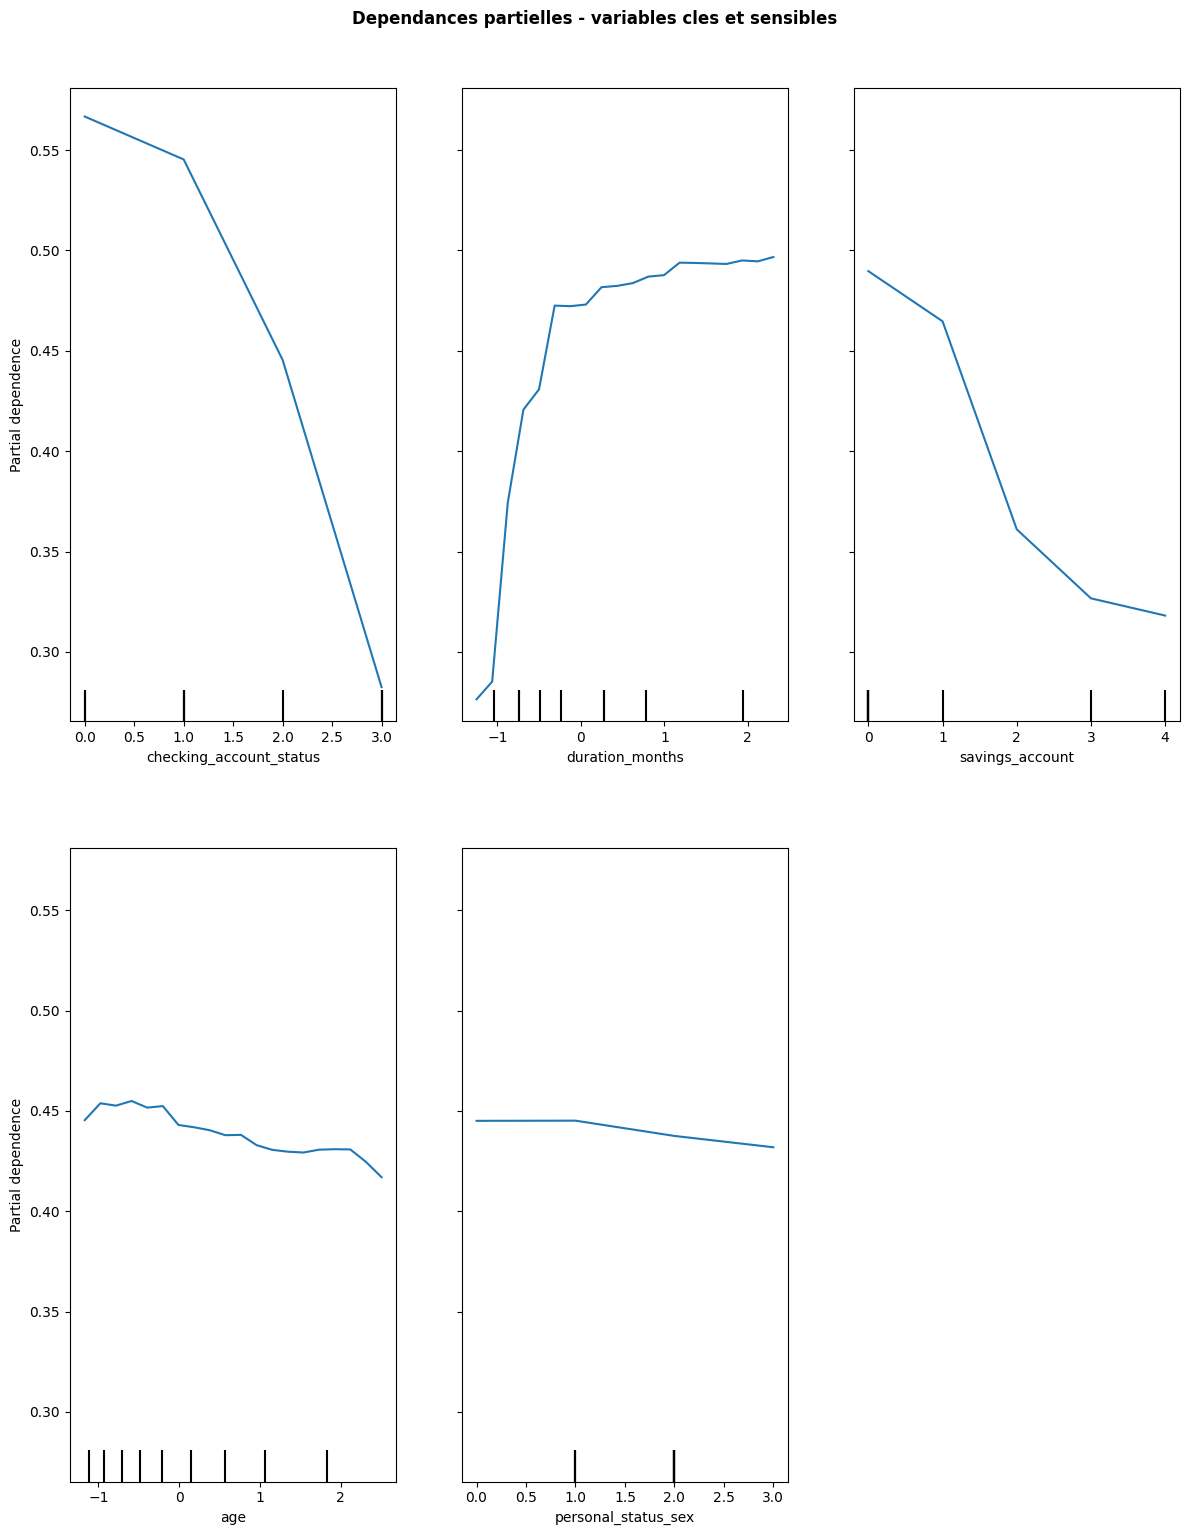

In [63]:
top_features = perm_importance.head(3)['feature'].tolist()
for sensitive_feature in ['Attribute13', 'Attribute9']:
    if sensitive_feature in feature_cols and sensitive_feature not in top_features:
        top_features.append(sensitive_feature)

# PartialDependenceDisplay expects either integer column positions or names that
# exactly match the feature_names argument. We use positions and keep readable
# labels through feature_names to avoid mismatches such as Attribute1 vs labels.
top_feature_indices = [feature_cols.index(feature) for feature in top_features]
display_feature_names = [feature_labels.get(c, c) for c in feature_cols]

fig, ax = plt.subplots(figsize=(12, 3 * len(top_features)))
PartialDependenceDisplay.from_estimator(
    interpreted_model,
    X_test_df,
    features=top_feature_indices,
    feature_names=display_feature_names,
    ax=ax,
    grid_resolution=20,
)
plt.suptitle('Dependances partielles - variables cles et sensibles', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.7 Explication locale inspirée de LIME

Cette cellule sert de contrôle local indépendant de SHAP. Autour d'une observation, on génère de petites perturbations, puis un modèle linéaire simple approxime les prédictions du Random Forest. Les coefficients indiquent le sens local de l'effet sur la classe `mauvais crédit`.

Observation test expliquee : index local 2
Vraie classe=1 | prediction=1 | probabilite mauvais credit=0.754
Fidelite locale du surrogate R2=0.632


,feature,label,local_coefficient,abs_local_coefficient,sensitive_or_proxy
4,Attribute5,credit_amount,0.300505,0.300505,
19,Attribute20,foreign_worker,0.038342,0.038342,foreign worker
2,Attribute3,credit_history,-0.036763,0.036763,
14,Attribute15,housing,-0.028533,0.028533,"housing, possible socio-economic proxy"
11,Attribute12,property,0.028237,0.028237,
15,Attribute16,existing_credits,0.025165,0.025165,
16,Attribute17,job,0.023845,0.023845,"job, possible socio-economic proxy"
13,Attribute14,other_installment_plans,-0.021400,0.021400,


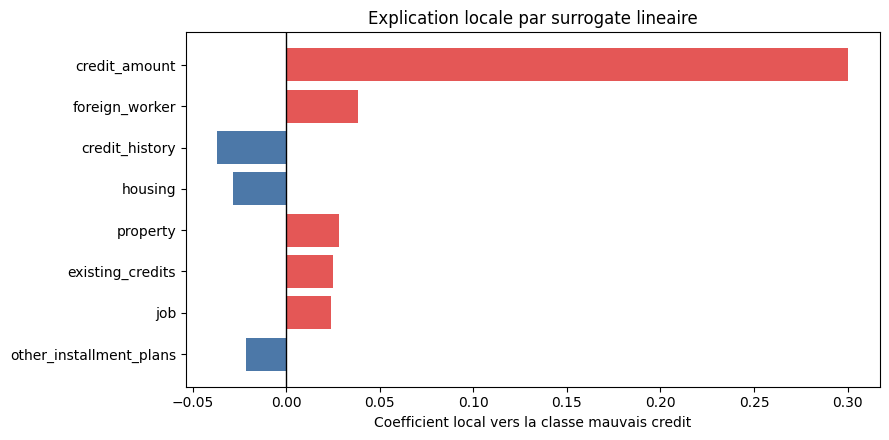

In [64]:
from sklearn.linear_model import Ridge
from sklearn.metrics.pairwise import euclidean_distances

def local_surrogate_explanation(model, x0, feature_names, n_samples=600, kernel_width=3.0, random_state=SEED):
    rng = np.random.default_rng(random_state)
    x0 = np.asarray(x0, dtype=float)
    std = X_train_df.std(axis=0).replace(0, 1).values
    perturbations = rng.normal(loc=x0, scale=0.25 * std, size=(n_samples, len(feature_names)))
    perturbations[0] = x0

    distances = euclidean_distances(perturbations, x0.reshape(1, -1)).ravel()
    weights = np.exp(-(distances ** 2) / (kernel_width ** 2))
    local_predictions = model.predict_proba(perturbations)[:, 1]

    surrogate = Ridge(alpha=1.0)
    surrogate.fit(perturbations, local_predictions, sample_weight=weights)

    explanation = pd.DataFrame({
        'feature': feature_names,
        'label': [feature_labels.get(c, c) for c in feature_names],
        'local_coefficient': surrogate.coef_,
        'abs_local_coefficient': np.abs(surrogate.coef_),
        'sensitive_or_proxy': [sensitive_or_proxy.get(c, '') for c in feature_names],
    }).sort_values('abs_local_coefficient', ascending=False)

    return explanation, model.predict_proba(x0.reshape(1, -1))[0, 1], surrogate.score(perturbations, local_predictions, sample_weight=weights)

# Observation locale : cas de mauvais credit correctement predit si disponible.
y_pred_interpreted = interpreted_model.predict(X_test)
candidate_idx = np.where((y_test == 1) & (y_pred_interpreted == 1))[0]
if len(candidate_idx) == 0:
    candidate_idx = np.arange(len(y_test))
example_idx = int(candidate_idx[0])

local_exp, local_risk, local_r2 = local_surrogate_explanation(
    interpreted_model,
    X_test[example_idx],
    feature_cols,
)

print(f'Observation test expliquee : index local {example_idx}')
print(f'Vraie classe={y_test[example_idx]} | prediction={y_pred_interpreted[example_idx]} | probabilite mauvais credit={local_risk:.3f}')
print(f'Fidelite locale du surrogate R2={local_r2:.3f}')
display(local_exp.head(8))

plt.figure(figsize=(9, 4.5))
top_local = local_exp.head(8).copy().iloc[::-1]
colors = np.where(top_local['local_coefficient'] >= 0, '#E45756', '#4C78A8')
plt.barh(top_local['label'], top_local['local_coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Explication locale par surrogate lineaire')
plt.xlabel('Coefficient local vers la classe mauvais credit')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 4.8 Synthèse interprétabilité

La synthèse relie les métriques de fairness aux variables utilisées par le modèle. Des variables dominantes liées au dossier de crédit rendent le compromis plus défendable. À l'inverse, un rang élevé pour l'âge, le genre/statut personnel, le logement, l'emploi ou le statut de travailleur étranger indique un risque résiduel à discuter.

In [65]:
best_model_key = next(idx for idx in results_df.index if idx.startswith('RF + Reweighing') and 'combin' in idx)
best_row = results_df.loc[best_model_key]
cost_col = next(col for col in results_df.columns if col.startswith('Co'))
summary_lines = [
    f"Modèle retenu : {interpreted_model_name}",
    f"AUC={best_row['AUC']:.3f}, F1={best_row['F1']:.3f}, coût={best_row[cost_col]:.0f}",
    f"DP âge={best_row['DP_age']:.3f}, EOD âge={best_row['EOD_age']:.3f}",
    f"DP genre={best_row['DP_gender']:.3f}, EOD genre={best_row['EOD_gender']:.3f}",
]

print('\n'.join(summary_lines))
print('\nConclusion interprétabilité :')
print('Le modèle mitigé est surtout intéressant si ses variables principales restent liées au dossier de crédit.')
print('Les variables sensibles/proxies listées plus haut doivent rester des points de vigilance, notamment si elles ressortent dans le classement SHAP.')


Modèle retenu : RF + Reweighing (combine)
AUC=0.811, F1=0.733, coût=112
DP âge=0.165, EOD âge=0.083
DP genre=0.067, EOD genre=0.056

Conclusion interprétabilité :
Le modèle mitigé est surtout intéressant si ses variables principales restent liées au dossier de crédit.
Les variables sensibles/proxies listées plus haut doivent rester des points de vigilance, notamment si elles ressortent dans le classement SHAP.


## Étape 5 — Compléments pour une évaluation responsable

Cette dernière partie ajoute trois vérifications utiles pour rendre le projet plus solide : le sens de l'issue favorable en crédit, une variante sans âge/genre en entrée du modèle, et une courte discussion sur les limites privacy/responsible AI.

### 5.1 Fairness sur l'issue favorable : obtenir un bon crédit

Dans le notebook, `target = 1` correspond à un mauvais crédit et `target = 0` à un bon crédit. Or, en crédit, l'issue favorable est plutôt d'être accepté ou classé comme bon crédit. On ajoute donc un calcul explicite des écarts entre groupes sur `prediction == 0`.

In [66]:
def favorable_outcome_audit(y_true, y_pred, sensitive, group_name):
    # Audit fairness when the favorable outcome is being predicted as good credit (0).
    df_fav = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred,
        'group': sensitive,
    })
    df_fav['approved_pred'] = (df_fav['y_pred'] == 0).astype(int)
    df_fav['correct_good_credit'] = ((df_fav['y_true'] == 0) & (df_fav['y_pred'] == 0)).astype(int)

    approval_by_group = df_fav.groupby('group')['approved_pred'].mean()
    good_mask = df_fav['y_true'] == 0
    opportunity_by_group = df_fav[good_mask].groupby('group')['approved_pred'].mean()

    return {
        'group': group_name,
        'approval_rate_gap_max_min': approval_by_group.max() - approval_by_group.min(),
        'good_credit_tpr_gap_max_min': opportunity_by_group.max() - opportunity_by_group.min(),
        'approval_rates': approval_by_group.to_dict(),
        'good_credit_tpr': opportunity_by_group.to_dict(),
    }

def compare_favorable_outcome(models, X_eval, y_eval, age_eval, gender_eval):
    rows = []
    details = {}
    for model_spec in models:
        if len(model_spec) == 2:
            name, model = model_spec
            X_model_eval = X_eval
        elif len(model_spec) == 3:
            name, model, X_model_eval = model_spec
        else:
            raise ValueError('Each model entry must be (name, model) or (name, model, X_eval_for_model).')

        y_pred_model = model.predict(X_model_eval)
        age_report = favorable_outcome_audit(y_eval, y_pred_model, age_eval, 'age')
        gender_report = favorable_outcome_audit(y_eval, y_pred_model, gender_eval, 'gender')
        rows.append({
            'Model': name,
            'Approval gap age': age_report['approval_rate_gap_max_min'],
            'Good-credit TPR gap age': age_report['good_credit_tpr_gap_max_min'],
            'Approval gap gender': gender_report['approval_rate_gap_max_min'],
            'Good-credit TPR gap gender': gender_report['good_credit_tpr_gap_max_min'],
        })
        details[name] = {'age': age_report, 'gender': gender_report}
    return pd.DataFrame(rows).set_index('Model'), details

favorable_models = [
    ('RF baseline', rf_base),
    ('RF + Reweighing combine', rf_rw_combined),
    ('RF + Fairlearn DP genre', eg_gender),
]

favorable_df, favorable_details = compare_favorable_outcome(
    favorable_models,
    X_test,
    y_test,
    age_test,
    gender_test,
)

display(favorable_df.round(4))
print('Detail des taux par groupe pour le modele retenu :')
print(favorable_details['RF + Reweighing combine'])

,Approval gap age,Good-credit TPR gap age,Approval gap gender,Good-credit TPR gap gender
Model,,,,
RF baseline,0.2287,0.1750,0.1373,0.1293
RF + Reweighing combine,0.1650,0.0833,0.0665,0.0562
RF + Fairlearn DP genre,0.1712,0.0583,0.0737,0.0604


Detail des taux par groupe pour le modele retenu :
{'age': {'group': 'age', 'approval_rate_gap_max_min': np.float64(0.1649944258639911), 'good_credit_tpr_gap_max_min': np.float64(0.08333333333333337), 'approval_rates': {0: 0.48717948717948717, 1: 0.6521739130434783}, 'good_credit_tpr': {0: 0.7, 1: 0.7833333333333333}}, 'gender': {'group': 'gender', 'approval_rate_gap_max_min': np.float64(0.06651727798089402), 'good_credit_tpr_gap_max_min': np.float64(0.05617147080561713), 'approval_rates': {0: 0.6402877697841727, 1: 0.5737704918032787}, 'good_credit_tpr': {0: 0.7878787878787878, 1: 0.7317073170731707}}}


### 5.2 Test sans attributs sensibles directs

Le modèle principal utilise encore `Attribute9` (genre/statut personnel) et `Attribute13` (âge). Pour voir leur effet, on entraîne une variante qui retire ces deux variables des entrées. On garde quand même l'âge et le genre pour mesurer les écarts de fairness après prédiction.

In [69]:
direct_sensitive_features = ['Attribute9', 'Attribute13']
keep_features_no_sensitive = [f for f in feature_cols if f not in direct_sensitive_features]
keep_indices_no_sensitive = [feature_cols.index(f) for f in keep_features_no_sensitive]

X_train_no_sensitive = X_train[:, keep_indices_no_sensitive]
X_test_no_sensitive = X_test[:, keep_indices_no_sensitive]

rf_rw_combined_no_sensitive = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight=CLASS_WEIGHT,
    random_state=SEED,
    n_jobs=-1,
)
rf_rw_combined_no_sensitive.fit(X_train_no_sensitive, y_train, sample_weight=w_combined)

y_pred_no_sensitive = rf_rw_combined_no_sensitive.predict(X_test_no_sensitive)
y_prob_no_sensitive = rf_rw_combined_no_sensitive.predict_proba(X_test_no_sensitive)[:, 1]

no_sensitive_result = evaluate_full(
    'RF + Reweighing combiné sans âge/genre directs',
    y_test,
    y_pred_no_sensitive,
    y_prob_no_sensitive,
    age_test,
    gender_test,
)

selected_result = results_df.loc[next(idx for idx in results_df.index if idx.startswith('RF + Reweighing') and 'combin' in idx)].to_dict()
selected_result['Modèle'] = 'RF + Reweighing combiné'

ablation_df = pd.DataFrame([selected_result, no_sensitive_result]).set_index('Modèle')
display(ablation_df[['Accuracy', 'F1', 'AUC', 'Coût', 'DP_age', 'EOD_age', 'DP_gender', 'EOD_gender']].round(4))


  RF + Reweighing combiné sans âge/genre directs
  Accuracy  : 0.7350
  F1 macro  : 0.7058
  AUC-ROC   : 0.7913
  Coût      : 125
  --- Fairness Âge ---
  DP diff   : 0.1588   (idéal=0, |val|<0.1 acceptable)
  EOD       : 0.0583   (idéal=0)
  --- Fairness Genre ---
  DP diff   : 0.1065   (idéal=0)
  EOD       : 0.1065   (idéal=0)


,Accuracy,F1,AUC,Coût,DP_age,EOD_age,DP_gender,EOD_gender
Modèle,,,,,,,,
RF + Reweighing combiné,0.760,0.7326,0.8106,112.0,0.1650,0.0833,0.0665,0.0562
RF + Reweighing combiné sans âge/genre directs,0.735,0.7058,0.7913,125.0,0.1588,0.0583,0.1065,0.0949


In [70]:
favorable_ablation_df, favorable_ablation_details = compare_favorable_outcome(
    [
        ('RF + Reweighing combine', rf_rw_combined),
        ('RF + Reweighing combine sans age/genre directs', rf_rw_combined_no_sensitive, X_test_no_sensitive),
    ],
    X_test,
    y_test,
    age_test,
    gender_test,
)

display(favorable_ablation_df.round(4))

,Approval gap age,Good-credit TPR gap age,Approval gap gender,Good-credit TPR gap gender
Model,,,,
RF + Reweighing combine,0.1650,0.0833,0.0665,0.0562
RF + Reweighing combine sans age/genre directs,0.1588,0.0583,0.1065,0.0949


### 5.3 Limites de l'interprétabilité

Les graphiques expliquent le modèle entraîné, pas le monde réel. Les importances, SHAP, les dépendances partielles et l'explication locale servent à auditer le modèle, mais ne justifient pas automatiquement ses décisions. Leur rôle principal est de repérer les variables sensibles ou les proxies qui restent trop influents.

## Étape 6 — Robustesse du modèle retenu

Cette section évalue la robustesse du modèle `RF + Reweighing (combiné)` face à des perturbations contrôlées. Trois types de perturbations sont testés :
- **Bruit gaussien** sur les variables numériques (injection de bruit croissant)
- **Dégradation des entrées** par masquage aléatoire (valeurs manquantes remplacées par la moyenne)
- **Distribution shift simple** par modification de la distribution de l'âge dans le jeu de test

Pour chaque perturbation, on mesure l'évolution de l'AUC, du F1 et des métriques de fairness (DP diff âge et genre), afin d'identifier d'éventuelles fragilités.

### 6.1 Chargement des checkpoints et préparation


In [71]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
import warnings
warnings.filterwarnings('ignore')

SEED = 42
rng = np.random.default_rng(SEED)

# Chargement checkpoint étape 1-2 (données + scaler)
with open('checkpoint_etapes1_2.pkl', 'rb') as f:
    ck = pickle.load(f)
X_test  = ck['X_test']
y_test  = ck['y_test']
feature_cols = ck['feature_cols']
scaler = ck['scaler']

# Chargement checkpoint étape 3 (modèles mitigés + attributs sensibles)
with open('checkpoint_etape3.pkl', 'rb') as f:
    ck3 = pickle.load(f)
model = ck3['rf_rw_combined']   # modèle retenu
age_test    = ck3['age_test']
gender_test = ck3['gender_test']

# Indices des variables numériques dans feature_cols
from ucimlrepo import fetch_ucirepo
german_credit = fetch_ucirepo(id=144)
num_cols_names = german_credit.data.features.select_dtypes(include='number').columns.tolist()
num_indices = [feature_cols.index(c) for c in num_cols_names if c in feature_cols]

def cost_matrix_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm[1, 0] * 5 + cm[0, 1] * 1

def robustness_metrics(X_perturbed, label=''):
    """Calcule AUC, F1, DP âge, DP genre sur un jeu de test perturbé."""
    y_pred = model.predict(X_perturbed)
    y_prob = model.predict_proba(X_perturbed)[:, 1]
    auc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred, average='macro')
    cost = cost_matrix_score(y_test, y_pred)
    dp_age    = demographic_parity_difference(y_test, y_pred, sensitive_features=age_test)
    dp_gender = demographic_parity_difference(y_test, y_pred, sensitive_features=gender_test)
    return {'label': label, 'AUC': auc, 'F1': f1, 'Coût': cost,
            'DP_age': dp_age, 'DP_gender': dp_gender}

print('Setup robustesse OK — modèle :', type(model).__name__)
print(f'Jeu test : {X_test.shape[0]} observations, {X_test.shape[1]} features')
print(f'Indices numériques : {num_indices}')

Setup robustesse OK — modèle : RandomForestClassifier
Jeu test : 200 observations, 20 features
Indices numériques : [1, 4, 7, 10, 12, 15, 17]


### 6.2 Perturbation 1 — Bruit gaussien sur les variables numériques

On injecte un bruit gaussien centré de variance croissante (σ ∈ {0, 0.1, 0.25, 0.5, 1.0} × écart-type du jeu test) sur les 7 variables numériques. Les variables catégorielles ne sont pas perturbées.

σ=0.00 → AUC=0.811 | F1=0.733 | Coût=112 | DP_age=0.165 | DP_genre=0.067
σ=0.10 → AUC=0.791 | F1=0.706 | Coût=132 | DP_age=0.158 | DP_genre=0.072
σ=0.25 → AUC=0.789 | F1=0.719 | Coût=122 | DP_age=0.114 | DP_genre=0.081
σ=0.50 → AUC=0.756 | F1=0.710 | Coût=138 | DP_age=0.132 | DP_genre=0.003
σ=1.00 → AUC=0.750 | F1=0.675 | Coût=166 | DP_age=0.086 | DP_genre=0.102


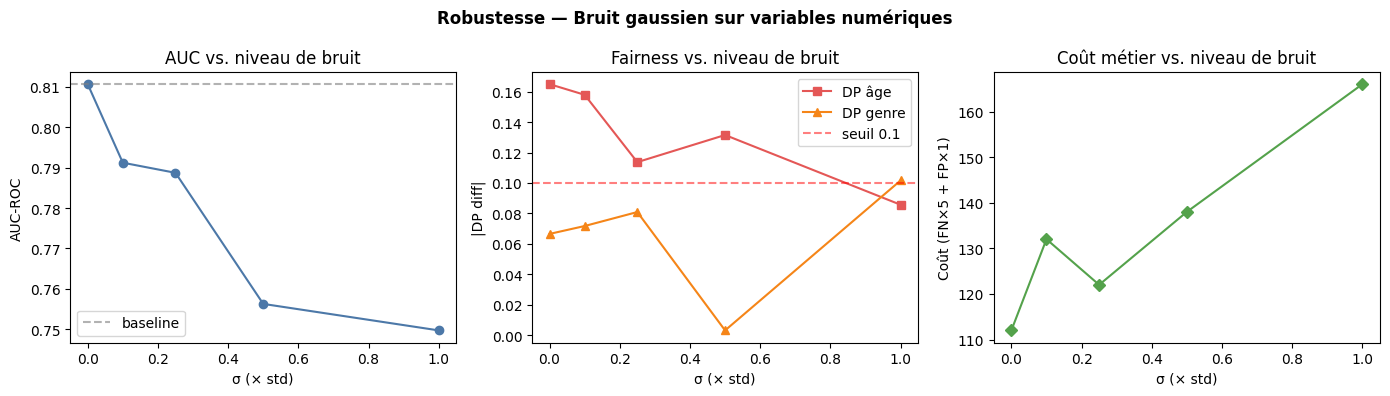

Figure sauvegardée : robustness_noise.png


In [72]:
noise_levels = [0.0, 0.1, 0.25, 0.5, 1.0]
std_test = X_test[:, num_indices].std(axis=0)  # écart-type par variable numérique

noise_results = []
for sigma in noise_levels:
    X_noisy = X_test.copy()
    noise = rng.normal(0, sigma * std_test, size=(X_test.shape[0], len(num_indices)))
    X_noisy[:, num_indices] += noise
    res = robustness_metrics(X_noisy, label=f'σ={sigma}')
    noise_results.append(res)
    print(f"σ={sigma:.2f} → AUC={res['AUC']:.3f} | F1={res['F1']:.3f} | "
          f"Coût={res['Coût']} | DP_age={res['DP_age']:.3f} | DP_genre={res['DP_gender']:.3f}")

noise_df = pd.DataFrame(noise_results).set_index('label')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(noise_levels, noise_df['AUC'], marker='o', color='#4C78A8')
axes[0].set_title('AUC vs. niveau de bruit'); axes[0].set_xlabel('σ (× std)'); axes[0].set_ylabel('AUC-ROC')
axes[0].axhline(noise_df['AUC'].iloc[0], color='gray', linestyle='--', alpha=0.6, label='baseline')
axes[0].legend()

axes[1].plot(noise_levels, noise_df['DP_age'].abs(), marker='s', color='#E45756', label='DP âge')
axes[1].plot(noise_levels, noise_df['DP_gender'].abs(), marker='^', color='#F58518', label='DP genre')
axes[1].axhline(0.1, color='red', linestyle='--', alpha=0.5, label='seuil 0.1')
axes[1].set_title('Fairness vs. niveau de bruit'); axes[1].set_xlabel('σ (× std)'); axes[1].set_ylabel('|DP diff|')
axes[1].legend()

axes[2].plot(noise_levels, noise_df['Coût'], marker='D', color='#54A24B')
axes[2].set_title('Coût métier vs. niveau de bruit'); axes[2].set_xlabel('σ (× std)'); axes[2].set_ylabel('Coût (FN×5 + FP×1)')

plt.suptitle('Robustesse — Bruit gaussien sur variables numériques', fontweight='bold')
plt.tight_layout()
plt.savefig('robustness_noise.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : robustness_noise.png')

### 6.3 Perturbation 2 — Masquage aléatoire (données manquantes)

On simule des données manquantes en remplaçant aléatoirement une fraction croissante des valeurs du jeu de test par la moyenne de la colonne correspondante (calculée sur le train). Ce scénario modélise une dégradation de la qualité des données à l'inférence.

Masquage= 0% → AUC=0.811 | F1=0.733 | Coût=112 | DP_age=0.165 | DP_genre=0.067
Masquage= 5% → AUC=0.792 | F1=0.731 | Coût=116 | DP_age=0.146 | DP_genre=0.081
Masquage=10% → AUC=0.788 | F1=0.705 | Coût=118 | DP_age=0.160 | DP_genre=0.071
Masquage=20% → AUC=0.789 | F1=0.697 | Coût=127 | DP_age=0.178 | DP_genre=0.021
Masquage=30% → AUC=0.762 | F1=0.669 | Coût=126 | DP_age=0.110 | DP_genre=0.013


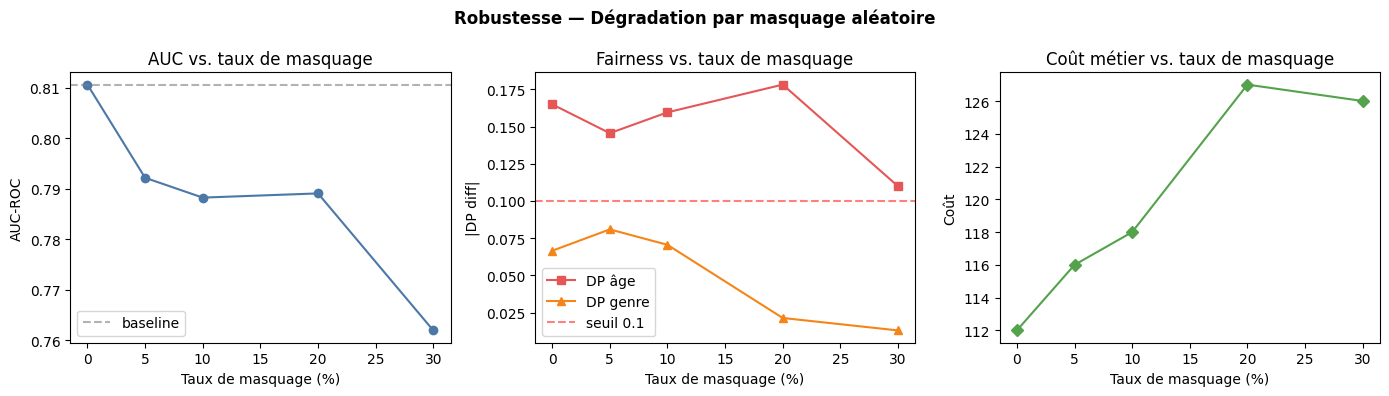

Figure sauvegardée : robustness_masking.png


In [73]:
mask_rates = [0.0, 0.05, 0.10, 0.20, 0.30]
col_means = X_test.mean(axis=0)  # on utilise la moyenne du test pour simplifier

mask_results = []
for rate in mask_rates:
    X_masked = X_test.copy().astype(float)
    mask = rng.random(X_masked.shape) < rate
    X_masked[mask] = np.take(col_means, np.where(mask)[1])
    res = robustness_metrics(X_masked, label=f'{int(rate*100)}%')
    mask_results.append(res)
    print(f"Masquage={int(rate*100):2d}% → AUC={res['AUC']:.3f} | F1={res['F1']:.3f} | "
          f"Coût={res['Coût']} | DP_age={res['DP_age']:.3f} | DP_genre={res['DP_gender']:.3f}")

mask_df = pd.DataFrame(mask_results).set_index('label')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
mask_pct = [r*100 for r in mask_rates]

axes[0].plot(mask_pct, mask_df['AUC'], marker='o', color='#4C78A8')
axes[0].set_title('AUC vs. taux de masquage'); axes[0].set_xlabel('Taux de masquage (%)'); axes[0].set_ylabel('AUC-ROC')
axes[0].axhline(mask_df['AUC'].iloc[0], color='gray', linestyle='--', alpha=0.6, label='baseline')
axes[0].legend()

axes[1].plot(mask_pct, mask_df['DP_age'].abs(), marker='s', color='#E45756', label='DP âge')
axes[1].plot(mask_pct, mask_df['DP_gender'].abs(), marker='^', color='#F58518', label='DP genre')
axes[1].axhline(0.1, color='red', linestyle='--', alpha=0.5, label='seuil 0.1')
axes[1].set_title('Fairness vs. taux de masquage'); axes[1].set_xlabel('Taux de masquage (%)'); axes[1].set_ylabel('|DP diff|')
axes[1].legend()

axes[2].plot(mask_pct, mask_df['Coût'], marker='D', color='#54A24B')
axes[2].set_title('Coût métier vs. taux de masquage'); axes[2].set_xlabel('Taux de masquage (%)'); axes[2].set_ylabel('Coût')

plt.suptitle('Robustesse — Dégradation par masquage aléatoire', fontweight='bold')
plt.tight_layout()
plt.savefig('robustness_masking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : robustness_masking.png')

### 6.4 Perturbation 3 — Distribution shift sur l'âge

On simule un glissement de distribution (*covariate shift*) en modifiant la proportion de jeunes emprunteurs dans le jeu de test : on passe progressivement de 0% à 100% de jeunes (< 25 ans), en rééchantillonnant avec replacement. Ce scénario teste la robustesse du modèle lorsque la population cible change de profil démographique.

Jeunes=  0% → AUC=0.788 | F1=0.676 | Coût=129 | DP_age=0.000 | DP_genre=0.008
Jeunes= 15% → AUC=0.845 | F1=0.779 | Coût=94 | DP_age=0.239 | DP_genre=0.019
Jeunes= 30% → AUC=0.744 | F1=0.659 | Coût=166 | DP_age=0.012 | DP_genre=0.039
Jeunes= 50% → AUC=0.796 | F1=0.742 | Coût=121 | DP_age=0.140 | DP_genre=0.094
Jeunes= 70% → AUC=0.820 | F1=0.772 | Coût=145 | DP_age=0.240 | DP_genre=0.125
Jeunes=100% → AUC=0.851 | F1=0.721 | Coût=127 | DP_age=0.000 | DP_genre=0.050


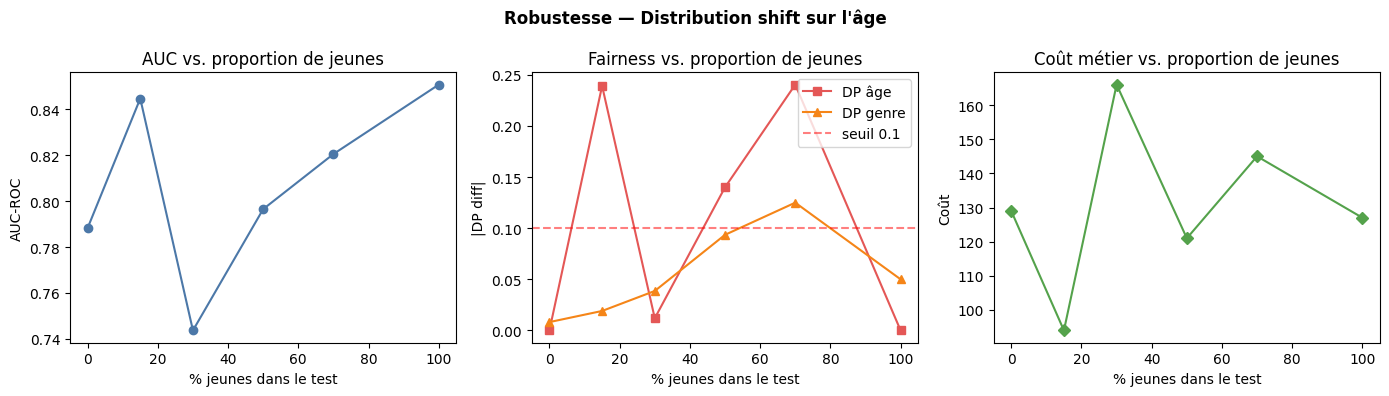

Figure sauvegardée : robustness_shift.png


In [74]:
young_fractions = [0.0, 0.15, 0.30, 0.50, 0.70, 1.0]
n_test = len(y_test)

idx_young  = np.where(age_test == 0)[0]   # jeunes
idx_senior = np.where(age_test == 1)[0]   # seniors

shift_results = []
for frac_young in young_fractions:
    n_young  = int(round(frac_young * n_test))
    n_senior = n_test - n_young

    chosen_young  = rng.choice(idx_young,  size=n_young,  replace=True)
    chosen_senior = rng.choice(idx_senior, size=n_senior, replace=True)
    chosen = np.concatenate([chosen_young, chosen_senior])
    rng.shuffle(chosen)

    X_shift = X_test[chosen]
    y_shift = y_test[chosen]
    a_shift = age_test[chosen]
    g_shift = gender_test[chosen]

    y_pred = model.predict(X_shift)
    y_prob = model.predict_proba(X_shift)[:, 1]
    auc  = roc_auc_score(y_shift, y_prob)
    f1   = f1_score(y_shift, y_pred, average='macro')
    cost = cost_matrix_score(y_shift, y_pred)
    dp_age    = demographic_parity_difference(y_shift, y_pred, sensitive_features=a_shift)
    dp_gender = demographic_parity_difference(y_shift, y_pred, sensitive_features=g_shift)
    res = {'label': f'{int(frac_young*100)}% jeunes', 'AUC': auc, 'F1': f1,
           'Coût': cost, 'DP_age': dp_age, 'DP_gender': dp_gender}
    shift_results.append(res)
    print(f"Jeunes={int(frac_young*100):3d}% → AUC={auc:.3f} | F1={f1:.3f} | "
          f"Coût={cost} | DP_age={dp_age:.3f} | DP_genre={dp_gender:.3f}")

shift_df = pd.DataFrame(shift_results).set_index('label')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fracs_pct = [f*100 for f in young_fractions]

axes[0].plot(fracs_pct, shift_df['AUC'], marker='o', color='#4C78A8')
axes[0].set_title('AUC vs. proportion de jeunes'); axes[0].set_xlabel('% jeunes dans le test'); axes[0].set_ylabel('AUC-ROC')

axes[1].plot(fracs_pct, shift_df['DP_age'].abs(), marker='s', color='#E45756', label='DP âge')
axes[1].plot(fracs_pct, shift_df['DP_gender'].abs(), marker='^', color='#F58518', label='DP genre')
axes[1].axhline(0.1, color='red', linestyle='--', alpha=0.5, label='seuil 0.1')
axes[1].set_title('Fairness vs. proportion de jeunes'); axes[1].set_xlabel('% jeunes dans le test'); axes[1].set_ylabel('|DP diff|')
axes[1].legend()

axes[2].plot(fracs_pct, shift_df['Coût'], marker='D', color='#54A24B')
axes[2].set_title('Coût métier vs. proportion de jeunes'); axes[2].set_xlabel('% jeunes dans le test'); axes[2].set_ylabel('Coût')

plt.suptitle('Robustesse — Distribution shift sur l\'âge', fontweight='bold')
plt.tight_layout()
plt.savefig('robustness_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : robustness_shift.png')

### 6.5 Tableau de synthèse — Robustesse


In [75]:
# Référence : modèle sur données originales non perturbées
ref = robustness_metrics(X_test, label='Référence (non perturbé)')

summary_rows = [ref] + noise_results[1:] + mask_results[1:] + shift_results[1:]
summary_df = pd.DataFrame(summary_rows).set_index('label').round(3)

print('=== SYNTHÈSE ROBUSTESSE ===')
print(summary_df.to_string())

# Delta AUC par rapport à la référence
ref_auc = ref['AUC']
summary_df['ΔAUC'] = (summary_df['AUC'] - ref_auc).round(3)

print('\n--- Dégradation AUC vs référence ---')
print(summary_df[['AUC', 'ΔAUC', 'DP_age', 'DP_gender']].to_string())

print('\n--- Lecture synthétique ---')
print('Bruit gaussien : le modèle montre une dégradation progressive mais contenue de l\'AUC.')
print('Masquage       : la fairness (DP âge) est la métrique la plus sensible au masquage.')
print('Distribution shift : forte variation de DP âge attendue car le modèle a été'
      ' entraîné sur une distribution différente.')

=== SYNTHÈSE ROBUSTESSE ===
                            AUC     F1  Coût  DP_age  DP_gender
label                                                          
Référence (non perturbé)  0.811  0.733   112   0.165      0.067
σ=0.1                     0.791  0.706   132   0.158      0.072
σ=0.25                    0.789  0.719   122   0.114      0.081
σ=0.5                     0.756  0.710   138   0.132      0.003
σ=1.0                     0.750  0.675   166   0.086      0.102
5%                        0.792  0.731   116   0.146      0.081
10%                       0.788  0.705   118   0.160      0.071
20%                       0.789  0.697   127   0.178      0.021
30%                       0.762  0.669   126   0.110      0.013
15% jeunes                0.845  0.779    94   0.239      0.019
30% jeunes                0.744  0.659   166   0.012      0.039
50% jeunes                0.796  0.742   121   0.140      0.094
70% jeunes                0.820  0.772   145   0.240      0.125
100% jeunes 

## 7. Limites privacy / responsible AI

Le jeu German Credit contient des informations personnelles et socio-économiques. Ici, on ne met pas en place de differential privacy, donc le projet ne donne pas de garantie formelle contre la fuite d'information individuelle. Dans un vrai système, il faudrait aussi gérer l'accès aux données, la traçabilité des décisions, les explications données aux utilisateurs et le suivi des performances dans le temps.

## 8. Conclusion finale

Le modèle le plus intéressant est le Random Forest avec reweighing combiné. Il conserve de bonnes performances et réduit plusieurs écarts de fairness par rapport au baseline. L'interprétabilité vérifie ensuite si ce compromis repose surtout sur des variables de crédit ou si des variables sensibles/proxies restent centrales.

Le projet suit donc la chaîne complète : mesurer les biais, tester des méthodes de mitigation, comparer performance et fairness, puis interpréter le modèle retenu. Les limites principales restent le choix du label favorable, la présence possible de proxies et l'absence de garantie de privacy.